# ZEC in UKESM analysis notebook

This notebook loads data and reproduces figures for manuscript

In [1]:
import os
import sys
import iris
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


In [2]:
def get_yrs_from_time_cube(time_cube):
    time_converted = time_cube.units.num2date(time_cube.points)
    yrs = np.asarray([time.year for time in time_converted])
    return yrs

In [3]:
def rolling_mean_on_arr(arr, window_size):
    if window_size == 0 or window_size is None:
        return arr
    else:
        max_index = int(np.floor((window_size-1)/2)) + 1
        start_roll = np.zeros_like(arr[:max_index])
        start_roll[0] = arr[0]
        for i in range(1, max_index):
            start_roll[i] = np.mean(arr[i:i*2+1])
        end_roll = np.convolve(arr[window_size-max_index:], np.ones(window_size)/window_size, mode='valid')
        roll = np.concatenate((start_roll, end_roll))
        return roll

In [4]:
# get window mean centred around time[0]: left cube is ramp up, right cube is stabilization run
def get_branch_point_mean(left_cube, right_cube, window_size, include_right_cube=True):
    left_cube_time = left_cube.coord('time')
    right_cube_time = right_cube.coord('time')
    a = None
    for i, time in enumerate(left_cube_time.points):
        # identify centre of window
        if time==right_cube_time.points[0]:
            a = i
    if a is None:
        sys.exit("No matching time points found - check whether time intercept has been removed")
    t0_window_left = left_cube[a-(window_size//2):a]
    t0_window_left_further = left_cube[a:a+(window_size//2)]
    if window_size % 2 != 0:
        t0_window_right = right_cube[:window_size//2+1]
    else:
        t0_window_right = right_cube[:window_size//2]
    if include_right_cube:
        t0_window = np.concatenate((t0_window_left.data, t0_window_right.data, t0_window_left_further.data))
    else:
        t0_window = t0_window_left.data
    return np.mean(t0_window)

In [5]:
SUITE_DICT = {
    'cy837': ['1.5K', 'blue'], 
    'cz834': ['1.5K', 'blue'], 
    'da087': ['1.5K', 'blue'], 
    'cy838': ['2.0K', 'green'], 
    'cz855': ['2.0K', 'green'], 
    'da266': ['2.0K', 'green'], 
    'cz375': ['3.0K', 'orange'], 
    'db587': ['3.0K', 'orange'], 
    'db597': ['3.0K', 'orange'], 
    'cz376': ['4.0K', 'orangered'], 
    'db723': ['4.0K', 'orangered'], 
    'db733': ['4.0K', 'orangered'], 
    'cz377': ['5.0K', 'darkred'], 
    'db731': ['5.0K', 'darkred'], 
    'dc324': ['5.0K', 'darkred'], 
}

RAMP_DICT = {
    'cx209': ['8PgC/Yr', 'black'],
    'cw988': ['8PgC/Yr', 'black'],
    'cw989': ['8PgC/Yr', 'black'],
}

ALL_DICT = RAMP_DICT | SUITE_DICT

suites = list(SUITE_DICT.keys())
ramp_suites = list(RAMP_DICT.keys())
# all_suites = suites + ramp_suites

suite_legend = {}
for suite, (suite, color) in ALL_DICT.items():
    if suite not in suite_legend:
        suite_legend[suite] = color
legend_handles = []

for suite, color in suite_legend.items():
    legend_handles.append(plt.Line2D([], [], color=color, linestyle='-', label=suite))

ENSEMBLE_LINEWIDTH = 0.9

def overlap_mean_from_latest_start(series_list):
    """Option 2: align at latest start year and truncate to shortest length."""
    cleaned = []
    for x, y in series_list:
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.any():
            cleaned.append((x[mask], y[mask]))
    if not cleaned:
        return np.array([]), np.array([])

    latest_start = max(x[0] for x, _ in cleaned)
    aligned = []
    for x, y in cleaned:
        i0 = np.searchsorted(x, latest_start, side='left')
        x_sub = x[i0:]
        y_sub = y[i0:]
        if len(x_sub) > 0:
            aligned.append((x_sub, y_sub))
    if not aligned:
        return np.array([]), np.array([])

    min_len = min(len(y) for _, y in aligned)
    if min_len == 0:
        return np.array([]), np.array([])

    x_mean = aligned[0][0][:min_len]
    y_stack = np.vstack([y[:min_len] for _, y in aligned])
    y_mean = np.nanmean(y_stack, axis=0)
    return x_mean, y_mean

In [6]:
# Data loading (per run + per variable) 
data_dir = 'paper_local_data/global_stats_per_run_var'
required_vars = [
    'co2GtC_glb_mean',
    'tas_glb_mean',
    'nbp_lnd_sum',
    'fgco2_ocn_sum',
]

def _var_path(run_name, var_name):
    return f"{data_dir}/{run_name}__{var_name}.nc"

def _load_local_var(path, var_name):
    cubes = iris.load(path)
    matches = [c for c in cubes if getattr(c, 'var_name', None) == var_name]
    if not matches:
        matches = [c for c in cubes if getattr(c, 'standard_name', None) == var_name or getattr(c, 'long_name', None) == var_name]
    if not matches:
        raise ValueError(f"No cube matching var '{var_name}' in {path}. Found: {[getattr(c,'var_name',None) for c in cubes]}")
    return matches[0]

for run_name in (suites + ramp_suites):
    for var_name in required_vars:
        lp = _var_path(run_name, var_name)
        if not os.path.exists(lp):
            raise FileNotFoundError(f"Missing local file: {lp}")

ramp_co2s, ramp_temps, ramp_nbps, ramp_ocn_co2s = [], [], [], []
for run_name in ramp_suites:
    ramp_co2s.append(_load_local_var(_var_path(run_name, 'co2GtC_glb_mean'), 'co2GtC_glb_mean'))
    ramp_temps.append(_load_local_var(_var_path(run_name, 'tas_glb_mean'), 'tas_glb_mean'))
    ramp_nbps.append(_load_local_var(_var_path(run_name, 'nbp_lnd_sum'), 'nbp_lnd_sum'))
    ramp_ocn_co2s.append(_load_local_var(_var_path(run_name, 'fgco2_ocn_sum'), 'fgco2_ocn_sum'))

co2s, temps, nbps, ocn_co2s = [], [], [], []
for run_name in suites:
    co2s.append(_load_local_var(_var_path(run_name, 'co2GtC_glb_mean'), 'co2GtC_glb_mean'))
    temps.append(_load_local_var(_var_path(run_name, 'tas_glb_mean'), 'tas_glb_mean'))
    nbps.append(_load_local_var(_var_path(run_name, 'nbp_lnd_sum'), 'nbp_lnd_sum'))
    ocn_co2s.append(_load_local_var(_var_path(run_name, 'fgco2_ocn_sum'), 'fgco2_ocn_sum'))

print(f"Loaded run from: {data_dir}")
print(f"Variables per run: {required_vars}")
print(f"ZE runs: {len(suites)}, ramp runs: {len(ramp_suites)}")


Loaded run from: paper_local_data/global_stats_per_run_var
Variables per run: ['co2GtC_glb_mean', 'tas_glb_mean', 'nbp_lnd_sum', 'fgco2_ocn_sum']
ZE runs: 15, ramp runs: 3


In [7]:
F2x=3.7 # from Armour et al. (2024, https://doi.org/10.1073/pnas.2312093121, Table S2)
beta=F2x/np.log(2)
R = beta
co2_ref=(ramp_co2s[0].data[0]+ramp_co2s[1].data[0]+ramp_co2s[2].data[0])/3

In [8]:
# Group suites by GWL while preserving SUITE_DICT insertion order.
_gwl_to_suites = defaultdict(list)
for _suite in suites:
    _gwl_to_suites[SUITE_DICT[_suite][0]].append(_suite)

# Map each suite to the ramp run it branched from.
suite_to_ramp_suite = {}
for _gwl, _members in _gwl_to_suites.items():
    if len(_members) > len(ramp_suites):
        raise ValueError(
            f"GWL {_gwl} has {len(_members)} members but only {len(ramp_suites)} ramp runs are available."
        )
    for _member_idx, _suite in enumerate(_members):
        suite_to_ramp_suite[_suite] = ramp_suites[_member_idx]

# Build lookup helpers for ramp years.
ramp_suite_to_years = {
    suite: np.asarray(get_yrs_from_time_cube(cube.coord('time')))
    for suite, cube in zip(ramp_suites, ramp_temps)
}

branch_dates = []
branch_idxs = []
for _suite, _temp_cube in zip(suites, temps):
    _suite_years = np.asarray(get_yrs_from_time_cube(_temp_cube.coord('time')))
    _branch_year = int(_suite_years[0])

    _ramp_suite = suite_to_ramp_suite[_suite]
    _ramp_years = ramp_suite_to_years[_ramp_suite]

    _matches = np.where(_ramp_years == _branch_year)[0]
    _branch_idx = int(_matches[0])
    # if len(_matches) > 0:
    # else:
    #     _branch_idx = int(np.argmin(np.abs(_ramp_years - _branch_year)))

    branch_dates.append(_branch_year)
    branch_idxs.append(_branch_idx)

branch_temp_centered_window_years = 31
ramp_suite_to_temp_data = {
    suite: np.asarray(cube.data, dtype=float)
    for suite, cube in zip(ramp_suites, ramp_temps)
}


def estimate_branch_temp_from_centered_mean(suite, branch_year, centered_window_years=31):
    ramp_suite = suite_to_ramp_suite[suite]
    ramp_years = np.asarray(ramp_suite_to_years[ramp_suite], dtype=float)
    ramp_temp = np.asarray(ramp_suite_to_temp_data[ramp_suite], dtype=float)

    half = centered_window_years // 2
    mask = (
        np.isfinite(ramp_years)
        & np.isfinite(ramp_temp)
        & (ramp_years >= branch_year - half)
        & (ramp_years <= branch_year + half)
    )
    if np.sum(mask) == 0:
        nearest_idx = int(np.argmin(np.abs(ramp_years - branch_year)))
        return float(ramp_temp[nearest_idx])
    return float(np.mean(ramp_temp[mask]))


suite_branch_temp_baseline = {
    suite: estimate_branch_temp_from_centered_mean(
        suite, branch_year, centered_window_years=branch_temp_centered_window_years
    )
    for suite, branch_year in zip(suites, branch_dates)
}

baseline_desc = (
    f"{branch_temp_centered_window_years}-year centered mean on matched ramp run around branch year"
)


/data/apps/sss/environments/default-2025_08_19/lib/python3.12/site-packages/iris/common/mixin.py:203: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


In [9]:
def get_ze_yrs_from_var(var):
    time = var.coord("time")
    time_converted = time.units.num2date(time.points)
    yrs = [time.year for time in time_converted]
    ze_yrs = [yr - yrs[0] for yr in yrs]
    return ze_yrs

In [10]:
def twolayermodel(timeyears, forcing, lambda_0, gamma, C_ml, C_deep, efficacy, T_ml0=0.0, T_deep0=0.0):

    result = {}
    dt = 60.*60.*24.*365. # time-step of one year in seconds
    nstep      = np.size(timeyears) # number of time-steps = numbers of years
    T_ml       = np.zeros(nstep)
    T_deep     = np.zeros(nstep)
    T_ml[0]    = T_ml0
    T_deep[0]  = T_deep0
    imbalance  = np.zeros(nstep)
    N_deep = np.zeros(nstep)
    N_mixed = np.zeros(nstep)
    deltaT = np.zeros(nstep)          # T_ml - T_deep
    ocean_flux = np.zeros(nstep)      # epsilon * gamma * (T_ml - T_deep)
    imbalance[0] = np.nan 
    N_deep[0] = np.nan
    N_mixed[0] = np.nan
    deltaT[0] = T_ml[0] - T_deep[0]
    ocean_flux[0] = efficacy * gamma * deltaT[0]

    for t in range(0, nstep-1):
        T_ml[t+1]      = T_ml[t] + (forcing[t]+lambda_0*T_ml[t]-efficacy*gamma*(T_ml[t]-T_deep[t]))*dt/C_ml
        T_deep[t+1]    = T_deep[t] + gamma*(T_ml[t]-T_deep[t])*dt/C_deep
        imbalance[t+1] = (C_ml*(T_ml[t+1]-T_ml[t]) + C_deep*(T_deep[t+1]-T_deep[t]))/dt
        N_deep[t+1] = gamma*(T_ml[t]-T_deep[t]) #*dt/C_deep
        N_mixed[t+1] = imbalance[t+1] - N_deep[t+1]

        deltaT[t+1] = T_ml[t+1] - T_deep[t+1]
        ocean_flux[t+1] = efficacy * gamma * deltaT[t+1]

    result['time'] = timeyears
    result['forcing'] = forcing
    result['T_ml'] = T_ml
    result['T_deep'] = T_deep
    result['imbalance'] = imbalance
    result['N_deep'] = N_deep
    result['N_mixed'] = N_mixed
    result['deltaT'] = deltaT
    result['ocean_flux'] = ocean_flux

    result['C_ml'] = C_ml
    result['C_deep'] = C_deep
    result['gamma'] = gamma
    result['lambda_0'] = lambda_0
    result['efficacy'] = efficacy
        
    return result


In [11]:
# Define values for two layer model calibrated to UKESM1.0-LL
# Values taken from Armour et al. (2024; https://doi.org/10.1073/pnas.2312093121)
# Supplementary Information, Table S2

nsecs_per_year = 60*60*24*365
C_ml    = 8.0 * nsecs_per_year 
C_deep  = 80 * nsecs_per_year 
gamma   = 0.52 # W/m2/K
efficacy = 1.13 # unitless
lambda_0 = -0.67 # W/m2/K

# Run the two layer model over the different scenarios
dFs = []
dyrs = []
dTs = []
dNs = []
dT0s = []
dNs_deep = []
dNs_mixed = []
T_T0_diffs = []
deep_ocn_uptake = []

for suite in suites:
    dF = np.load(f'EBM_files/dF_{suite}.npy')
    dFs.append(dF)
    timeyears = np.load(f'EBM_files/yr_{suite}.npy')
    experiment = twolayermodel(timeyears, dF, lambda_0, gamma, C_ml, C_deep, efficacy)
    dyrs.append(experiment['time'])
    dTs.append(experiment['T_ml'])
    dNs.append(experiment['imbalance'])
    dT0s.append(experiment['T_deep'])
    dNs_deep.append(experiment['N_deep'])
    dNs_mixed.append(experiment['N_mixed'])
    T_T0_diffs.append(experiment['deltaT'])
    deep_ocn_uptake.append(experiment['ocean_flux'])

In [12]:
# Choose ZEC years
nyrs = [50, 150]
zec_window_years = 20  # centered 20-year window: [X-10, X+9]
zec_half_window = zec_window_years // 2

def zec_x_centered_window(series, branch_idx, x_year, half_window=10, baseline_temp=None):
    """ZEC_X from one run: anomaly relative to baseline, averaged over [X-10, X+9]."""
    s = np.asarray(series)
    bidx = int(branch_idx)
    start = bidx + (x_year - half_window)
    end = bidx + (x_year + half_window)  

    if bidx < 0 or bidx >= len(s) or start < 0 or end > len(s):
        return np.nan

    branch_temp = s[bidx] if baseline_temp is None else baseline_temp
    return np.mean(s[start:end] - branch_temp)


all_dTs_xxx_aogcm_selected_baseline = []
ukesm_ZECs = []  
all_dTs_xxx_ebm = []  

for nyr in nyrs:
    zec_members_aogcm = []
    zec_members_ebm = []

    for suite, temp in zip(suites, temps):
        temp_data = np.asarray(temp.data, dtype=float)
        zec_val = zec_x_centered_window(
            temp_data,
            0,
            nyr,
            half_window=zec_half_window,
            baseline_temp=suite_branch_temp_baseline[suite],
        )
        zec_members_aogcm.append(zec_val)

    for suite, branch_idx, dT in zip(suites, branch_idxs, dTs):
        dT = np.asarray(dT)
        zec_val = zec_x_centered_window(dT, branch_idx, nyr, half_window=zec_half_window)
        zec_members_ebm.append(zec_val)

    all_dTs_xxx_aogcm_selected_baseline.append(zec_members_aogcm)
    ukesm_ZECs.append(zec_members_aogcm.copy())
    all_dTs_xxx_ebm.append(zec_members_ebm)

all_dTs_xxx = all_dTs_xxx_aogcm_selected_baseline

all_dTs_xxx_members = all_dTs_xxx
ukesm_ZECs_members = ukesm_ZECs

ordered_gwls = sorted({SUITE_DICT[s][0] for s in suites}, key=lambda g: float(str(g).replace('K','')))
gwl_to_indices = {gwl: [idx for idx, s in enumerate(suites) if SUITE_DICT[s][0] == gwl] for gwl in ordered_gwls}

all_dTs_xxx_plot = all_dTs_xxx_members
ukesm_ZECs_plot = ukesm_ZECs_members


In [13]:
# Now do constant F : emulating committed warming
dFs_const = []
yrs_const = []
dTs_const = []
dT0s_const = []
dNs_const = []
dNs_deep_const = []
dNs_mixed_const = []
T_T0_diffs_const = []
deep_ocn_uptake_const = []
for suite in suites:
    dF = np.load(f'EBM_files/dF_{suite}_const.npy')
    timeyears = np.load(f'EBM_files/yr_{suite}_const.npy')
    experiment = twolayermodel(timeyears, dF, lambda_0, gamma, C_ml, C_deep, efficacy)
    yrs_const.append(experiment['time'])
    dTs_const.append(experiment['T_ml'])
    dT0s_const.append(experiment['T_deep'])
    dNs_const.append(experiment['imbalance'])
    dFs_const.append(dF)
    dNs_deep_const.append(experiment['N_deep'])
    dNs_mixed_const.append(experiment['N_mixed'])
    T_T0_diffs_const.append(experiment['deltaT'])
    deep_ocn_uptake_const.append(experiment['ocean_flux'])

In [14]:
# Running the CC part for just after the point of ZE
dFs_CC_ZE_only = []
yrs_CC_ZE_only = []
dTs_CC_ZE_only = []
dNs_CC_ZE_only = []

for suite in suites:
    dF = np.load(f'EBM_files/dF_{suite}_CC_ZE_only.npy')
    timeyears = np.load(f'EBM_files/yr_{suite}_CC_ZE_only.npy')
    experiment = twolayermodel(timeyears, dF, lambda_0, gamma, C_ml, C_deep, efficacy)
    yrs_CC_ZE_only.append(experiment['time'])
    dTs_CC_ZE_only.append(experiment['T_ml'])
    dNs_CC_ZE_only.append(experiment['imbalance'])
    dFs_CC_ZE_only.append(dF)

In [15]:
all_dTs_const_xxx = []
for nyr in nyrs:
    dTs_const_xxx = []
    for suite, branch_idx, dT in zip(suites, branch_idxs, dTs_const):
        dT = np.asarray(dT)
        dT_const_xxx = zec_x_centered_window(dT, branch_idx, nyr, half_window=zec_half_window)
        dTs_const_xxx.append(dT_const_xxx)
    all_dTs_const_xxx.append(dTs_const_xxx)

In [16]:
all_dTs_CC_ZE_only_xxx = []
for nyr in nyrs:
    dTs_CC_ZE_only_xxx = []
    for suite, branch_date, yr_cc, dT in zip(suites, branch_dates, yrs_CC_ZE_only, dTs_CC_ZE_only):
        dT = np.asarray(dT)
        yr_cc = np.asarray(yr_cc)

        matches = np.where(yr_cc == branch_date)[0]
        bidx_cc = int(matches[0]) if len(matches) > 0 else 0

        dT_CC_ZE_only_xxx = zec_x_centered_window(dT, bidx_cc, nyr, half_window=zec_half_window)
        dTs_CC_ZE_only_xxx.append(dT_CC_ZE_only_xxx)

    all_dTs_CC_ZE_only_xxx.append(dTs_CC_ZE_only_xxx)

In [17]:
ZECs = all_dTs_xxx_ebm
CCs = all_dTs_CC_ZE_only_xxx

# CWs_direct = all_dTs_const_xxx
CWs = []
for zec_row, csc_row in zip(ZECs, CCs):
    CWs.append([
        (z - c) if (np.isfinite(z) and np.isfinite(c)) else np.nan
        for z, c in zip(zec_row, csc_row)
    ])

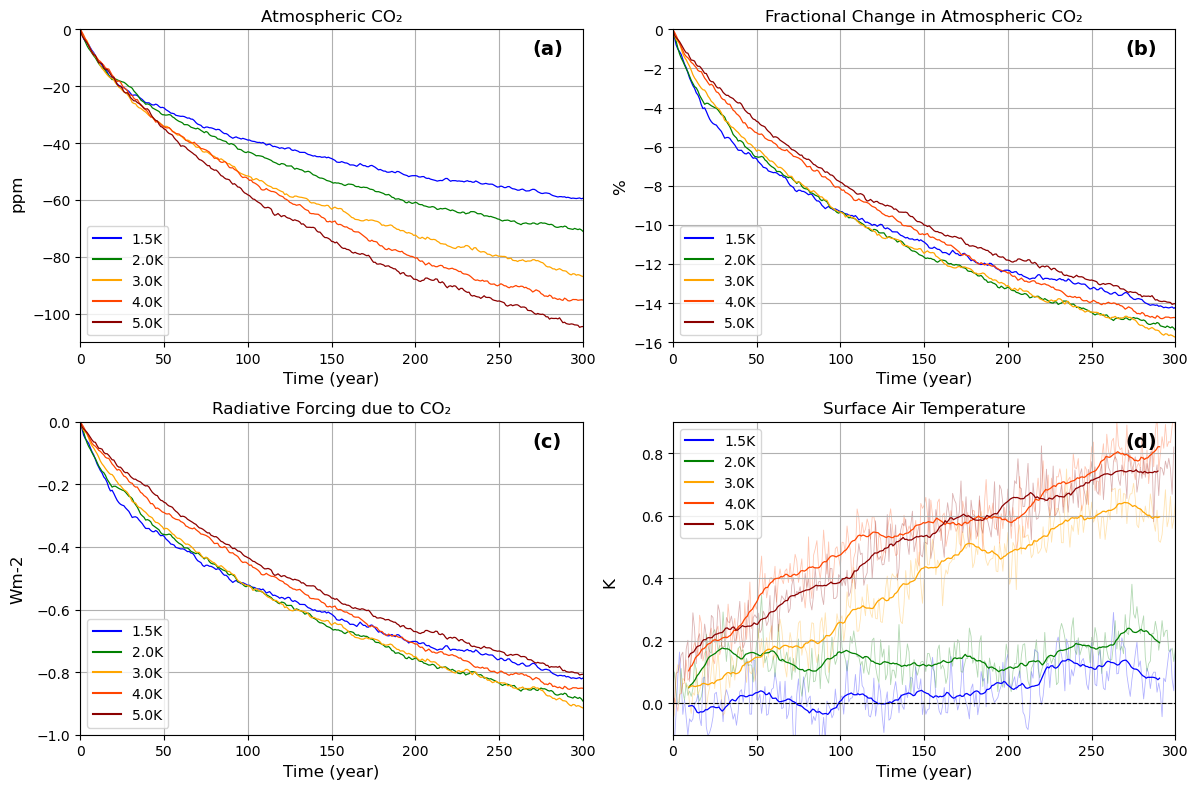

In [18]:
# Plot the ZE responses across all runs - paper fig 1

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
temp_window_size = 20
co2_window_size = 0
ppm_conversion = 1/2.13

def _plot_ensemble_mean_only(ax, suite_series, *, linestyle='-'):
    grouped = {}
    for suite, x, y in suite_series:
        gwl = SUITE_DICT[suite][0]
        grouped.setdefault(gwl, []).append((np.asarray(x), np.asarray(y)))

    for gwl in sorted(grouped.keys(), key=lambda g: float(str(g).replace('K',''))):
        x_mean, y_mean = overlap_mean_from_latest_start(grouped[gwl])
        if len(x_mean) == 0:
            continue
        color = SUITE_DICT[next(s for s in suites if SUITE_DICT[s][0] == gwl)][1]
        ax.plot(x_mean, y_mean, color=color, linewidth=ENSEMBLE_LINEWIDTH, linestyle=linestyle)

temp_series = []
temp_series_raw = []
co2_series = []
frac_series = []
df_series = []

for i, (co2, temp, dF, suite, dF_yr, branch_idx) in enumerate(zip(co2s, temps, dFs, suites, dyrs, branch_idxs)):

    ze_t_yrs = np.asarray(get_ze_yrs_from_var(temp), dtype=float)
    temp_data = np.asarray(temp.data, dtype=float)

    # Temperature anomaly relative to the selected ramp-derived cessation-temperature baseline.
    branch_temp = suite_branch_temp_baseline[suite]
    ze_temp_raw = temp_data - branch_temp
    ze_t_yrs_raw = np.asarray(get_ze_yrs_from_var(temp), dtype=float)
    if i == len(suites)-1:
        ze_t_yrs_raw = ze_t_yrs_raw[:-1]
        ze_temp_raw = ze_temp_raw[:-1]
    temp_series_raw.append((suite, np.asarray(ze_t_yrs_raw), np.asarray(ze_temp_raw)))

    ze_temp = np.asarray(ze_temp_raw, dtype=float)
    ze_t_yrs = np.asarray(ze_t_yrs_raw, dtype=float)
    if temp_window_size != 0:
        ze_temp = np.convolve(ze_temp, np.ones(temp_window_size)/temp_window_size, mode='valid')
        ze_t_yrs = np.convolve(ze_t_yrs, np.ones(temp_window_size)/temp_window_size, mode='valid')
    temp_series.append((suite, np.asarray(ze_t_yrs), np.asarray(ze_temp)))

    ze_c_yrs = get_ze_yrs_from_var(co2)
    co2 = co2.data * ppm_conversion
    dC = co2 - co2[0]
    frac = dC / co2[0]
    ze_co2 = [t - co2[0] for t in co2]
    if co2_window_size != 0:
        ze_co2 = np.convolve(ze_co2, np.ones(co2_window_size)/co2_window_size, mode='valid')
        frac = np.convolve(frac, np.ones(co2_window_size)/co2_window_size, mode='valid')
        ze_c_yrs = np.convolve(ze_c_yrs, np.ones(co2_window_size)/co2_window_size, mode='valid')
    co2_series.append((suite, np.asarray(ze_c_yrs), np.asarray(ze_co2) - ze_co2[0]))
    frac_series.append((suite, np.asarray(ze_c_yrs), 100.0 * np.asarray(frac)))

    idx = int(branch_idx)
    ze_dF_yr = dF_yr[idx:] - dF_yr[idx]
    ze_dF = dF[idx:] - dF[idx]
    df_series.append((suite, np.asarray(ze_dF_yr), np.asarray(ze_dF)))

# ZEC spread diagnostics (std across members) at selected years since ZE
eval_years = [50, 100, 150, 200, 250]
zec_window_stats_by_gwl = {}
zec_std_by_gwl = {}

grouped_temp = {}
for suite, x_vals, y_vals in temp_series:
    gwl = SUITE_DICT[suite][0]
    grouped_temp.setdefault(gwl, []).append((np.asarray(x_vals, dtype=float), np.asarray(y_vals, dtype=float)))

grouped_temp_zec_windows = {}
for suite, x_vals, y_vals in temp_series_raw:
    gwl = SUITE_DICT[suite][0]
    grouped_temp_zec_windows.setdefault(gwl, []).append((np.asarray(x_vals, dtype=float), np.asarray(y_vals, dtype=float)))

zec_half_window = 10  # centered 20-year window: [X-10, X+10)
def _window_mean_at_year(x_vals, y_vals, target_year, half_window=10):
    x_vals = np.asarray(x_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)
    mask = np.isfinite(x_vals) & np.isfinite(y_vals) & (x_vals >= (target_year - half_window)) & (x_vals < (target_year + half_window))
    if not np.any(mask):
        return np.nan
    return float(np.nanmean(y_vals[mask]))

def _window_member_values_at_year(series_list, target_year, half_window=10):
    member_vals = []
    for x_vals, y_vals in series_list:
        if len(x_vals) == 0:
            continue
        w_val = _window_mean_at_year(x_vals, y_vals, target_year, half_window=half_window)
        if np.isfinite(w_val):
            member_vals.append(float(w_val))
    return np.asarray(member_vals, dtype=float)

for gwl in sorted(grouped_temp_zec_windows.keys(), key=lambda g: float(str(g).replace('K', ''))):
    zec_window_stats_by_gwl[gwl] = {}
    zec_std_by_gwl[gwl] = {}
    for target_year in eval_years:
        member_vals = _window_member_values_at_year(grouped_temp_zec_windows[gwl], target_year, half_window=zec_half_window)

        zec_mean = float(np.mean(member_vals)) if member_vals.size >= 1 else np.nan
        zec_std = float(np.std(member_vals, ddof=1)) if member_vals.size >= 2 else np.nan
        zec_window_stats_by_gwl[gwl][target_year] = (zec_mean, zec_std)
        zec_std_by_gwl[gwl][target_year] = zec_std

grouped_co2 = {}
for suite, x_vals, y_vals in co2_series:
    gwl = SUITE_DICT[suite][0]
    grouped_co2.setdefault(gwl, []).append((np.asarray(x_vals, dtype=float), np.asarray(y_vals, dtype=float)))


_plot_ensemble_mean_only(ax[1,1], temp_series)
_plot_ensemble_mean_only(ax[0,0], co2_series)
_plot_ensemble_mean_only(ax[0,1], frac_series)
_plot_ensemble_mean_only(ax[1,0], df_series)

grouped_temp_raw = {}
for suite, x_vals, y_vals in temp_series_raw:
    gwl = SUITE_DICT[suite][0]
    grouped_temp_raw.setdefault(gwl, []).append((np.asarray(x_vals), np.asarray(y_vals)))

for gwl in sorted(grouped_temp_raw.keys(), key=lambda g: float(str(g).replace('K',''))):
    x_raw, y_raw = overlap_mean_from_latest_start(grouped_temp_raw[gwl])
    if len(x_raw) == 0:
        continue
    color = SUITE_DICT[next(s for s in suites if SUITE_DICT[s][0] == gwl)][1]
    ax[1,1].plot(x_raw, y_raw, color=color, linewidth=0.6, alpha=0.3, linestyle='-', zorder=0)

y_time_lim = 300
for a in ax.flatten():
    a.grid()
    a.set_xlabel('Time (year)', fontsize=12)
    a.set_xlim((0, y_time_lim))
ax[0,0].set_ylim((-110,0))
ax[0,1].set_ylim((-16,0))
ax[1,0].set_ylim((-1,0))
ax[1,1].set_ylim((-0.1,0.9))

ax[0,0].set_ylabel('ppm', fontsize=12)
ax[0,1].set_ylabel('%', fontsize=12)
ax[1,1].set_ylabel('K', fontsize=12)
ax[1,0].set_ylabel('Wm-2', fontsize=12)
# add axhlin to temp plot
ax[1,1].axhline(0, color='black', linestyle='--', linewidth=0.8)

ax[0,0].legend(handles=legend_handles[1:], loc='lower left')
ax[0,1].legend(handles=legend_handles[1:], loc='lower left')
ax[1,0].legend(handles=legend_handles[1:], loc='lower left')
ax[1,1].legend(handles=legend_handles[1:], loc='best')

ax[0,0].text(0.9,0.92,'(a)', transform=ax[0,0].transAxes, fontsize=14, fontweight="bold")
ax[0,1].text(0.9,0.92,'(b)', transform=ax[0,1].transAxes, fontsize=14, fontweight="bold")
ax[1,0].text(0.9,0.92,'(c)', transform=ax[1,0].transAxes, fontsize=14, fontweight="bold")
ax[1,1].text(0.9,0.92,'(d)', transform=ax[1,1].transAxes, fontsize=14, fontweight="bold")

ax[0,0].yaxis.set_label_coords(-0.11, 0.48)
ax[1,1].yaxis.set_label_coords(-0.11, 0.49)
ax[1,0].yaxis.set_label_coords(-0.11, 0.5)
ax[0,0].set_title('Atmospheric CO₂')
ax[0,1].set_title('Fractional Change in Atmospheric CO₂')
ax[1,0].set_title('Radiative Forcing due to CO₂')
ax[1,1].set_title('Surface Air Temperature')

fig.tight_layout()

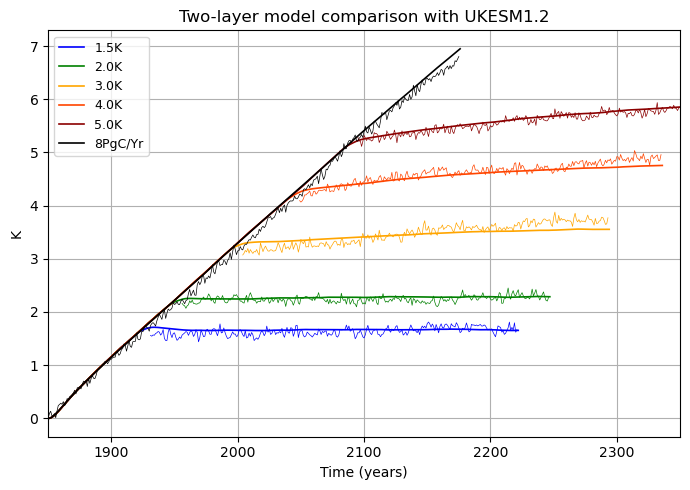

In [19]:
# Paper fig 2
# Ensemble-mean comparison: EBM vs AOGCM
# AOGCM is thinner solid; EBM is thicker dashed.

T_ref = (ramp_temps[0].data[0] + ramp_temps[1].data[0] + ramp_temps[2].data[0]) / 3

ordered_gwls = sorted({SUITE_DICT[s][0] for s in suites}, key=lambda g: float(str(g).replace('K','')))
gwl_to_indices = {gwl: [idx for idx, s in enumerate(suites) if SUITE_DICT[s][0] == gwl] for gwl in ordered_gwls}
gwl_to_color = {gwl: SUITE_DICT[next(s for s in suites if SUITE_DICT[s][0] == gwl)][1] for gwl in ordered_gwls}

fig, ax = plt.subplots(figsize=(7,5))

# Plot GWL ensemble means (AOGCM + EBM)
for gwl in ordered_gwls:
    idxs = gwl_to_indices[gwl]

    # EBM ensemble mean (dTs/dyrs)
    ebm_members = [(np.asarray(dyrs[j]), np.asarray(dTs[j])) for j in idxs]
    x_ebm, y_ebm = overlap_mean_from_latest_start(ebm_members)
    if len(x_ebm) > 0:
        ax.plot(x_ebm, y_ebm, color=gwl_to_color[gwl], linewidth=1.2, linestyle='-')

    # AOGCM ensemble mean (temps)
    aogcm_members = []
    for j in idxs:
        t = temps[j]
        aogcm_members.append((np.asarray(t.coord('year').points[0:-1]), np.asarray(t.data[0:-1] - T_ref)))
    x_aogcm, y_aogcm = overlap_mean_from_latest_start(aogcm_members)
    if len(x_aogcm) > 0:
        ax.plot(x_aogcm, y_aogcm, color=gwl_to_color[gwl], linewidth=0.5, linestyle='-')

F2x = 3.7
beta = F2x / np.log(2)
co2_ref = (ramp_co2s[0].data[0] + ramp_co2s[1].data[0] + ramp_co2s[2].data[0]) / 3

ramp_aogcm_members = []
ramp_ebm_members = []
for ramp_co2, ramp_temp in zip(ramp_co2s, ramp_temps):
    ramp_years = np.asarray(ramp_temp.coord('year').points)

    # AOGCM ramp anomaly
    ramp_aogcm_members.append((np.asarray(ramp_years[0:-1]), np.asarray(ramp_temp.data[0:-1] - T_ref)))

    # EBM ramp anomaly from ramp forcing only
    ramp_forcing = beta * np.log(ramp_co2.data / co2_ref)
    ramp_exp = twolayermodel(ramp_years, ramp_forcing, lambda_0, gamma, C_ml, C_deep, efficacy)
    ramp_ebm_members.append((np.asarray(ramp_exp['time']), np.asarray(ramp_exp['T_ml'])))

x_ramp_a, y_ramp_a = overlap_mean_from_latest_start(ramp_aogcm_members)
x_ramp_e, y_ramp_e = overlap_mean_from_latest_start(ramp_ebm_members)
if len(x_ramp_e) > 0:
    ax.plot(x_ramp_e, y_ramp_e, color='black', linewidth=1.2, linestyle='-')
if len(x_ramp_a) > 0:
    ax.plot(x_ramp_a, y_ramp_a, color='black', linewidth=0.5, linestyle='-')

# Minimal legend: colors = GWL only
from matplotlib.lines import Line2D
color_handles = [
    Line2D([0], [0], color=gwl_to_color[gwl], lw=1.2, label=gwl)
    for gwl in ordered_gwls
]
color_handles.append(Line2D([0], [0], color='black', lw=1.2, label='8PgC/Yr'))
ax.legend(handles=color_handles, loc='best', fontsize=9)

ax.set_xlim(1850, 2350)
ax.grid()
ax.set_xlabel('Time (years)')
ax.set_ylabel('K')
ax.set_title('Two-layer model comparison with UKESM1.2')

plt.tight_layout()


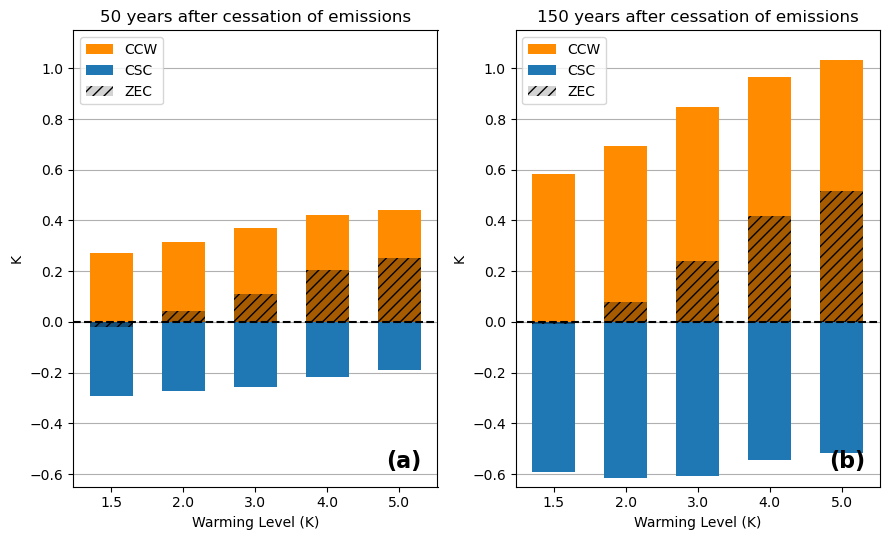

In [20]:
# Paper fig 3
# Plot the CCW and CSC bars (ensemble mean per GWL)

def _gwl_sort_key(gwl_label):
    return float(str(gwl_label).replace('K', ''))

# Map suite indices by GWL using suite order from `suites`.
ordered_gwls = sorted({SUITE_DICT[s][0] for s in suites}, key=_gwl_sort_key)
gwl_to_indices = {gwl: [idx for idx, s in enumerate(suites) if SUITE_DICT[s][0] == gwl] for gwl in ordered_gwls}

x = np.arange(len(ordered_gwls))
fig, axes = plt.subplots(1, len(nyrs), figsize=(9,5.5))

for i, (yr, ax) in enumerate(zip(nyrs, axes)):
    width = 0.6  # bar width

    # Ensemble mean across members in each GWL (ignore NaNs from short runs/missing years).
    zec_mean = [np.nanmean([ZECs[i][k] for k in gwl_to_indices[gwl]]) for gwl in ordered_gwls]
    ccw_mean = [np.nanmean([CWs[i][k] for k in gwl_to_indices[gwl]]) for gwl in ordered_gwls]
    csc_mean = [np.nanmean([CCs[i][k] for k in gwl_to_indices[gwl]]) for gwl in ordered_gwls]

    ax.bar(x, ccw_mean, width, label='CCW', color='darkorange')
    ax.bar(x, csc_mean, width, label='CSC')
    ax.bar(x, zec_mean, width, label='_nolegend_', color='black', alpha=0.35)
    ax.bar(x, zec_mean, width, label='ZEC', facecolor='none', hatch='///', linewidth=1.0)

    ax.set_xticks(x)
    ax.set_xticklabels([float(str(g).replace('K','')) for g in ordered_gwls])
    ax.set_xlabel('Warming Level (K)')
    ax.set_ylim(-0.65, 1.15)

    ax.axhline(color='black', linestyle='--')
    ax.grid(axis='y')
    ax.set_axisbelow(True)
    from matplotlib.patches import Patch
    bar_legend_handles = [
        Patch(facecolor='darkorange', edgecolor='none', label='CCW'),
        Patch(facecolor='C0', edgecolor='none', label='CSC'),
        Patch(facecolor='lightgrey', hatch='///', label='ZEC'),
    ]
    ax.legend(handles=bar_legend_handles, loc='upper left')
    ax.set_ylabel('K')
    ax.set_title(f"{yr} years after cessation of emissions")

    zec_stats = []
    ccw_stats = []
    csc_stats = []
    for gwl in ordered_gwls:
        zec_vals = np.asarray([ZECs[i][k] for k in gwl_to_indices[gwl]], dtype=float)
        ccw_vals = np.asarray([CWs[i][k] for k in gwl_to_indices[gwl]], dtype=float)
        csc_vals = np.asarray([CCs[i][k] for k in gwl_to_indices[gwl]], dtype=float)

        zec_vals = zec_vals[np.isfinite(zec_vals)]
        ccw_vals = ccw_vals[np.isfinite(ccw_vals)]
        csc_vals = csc_vals[np.isfinite(csc_vals)]

        zec_mean_v = float(np.mean(zec_vals)) if zec_vals.size else np.nan
        ccw_mean_v = float(np.mean(ccw_vals)) if ccw_vals.size else np.nan
        csc_mean_v = float(np.mean(csc_vals)) if csc_vals.size else np.nan

        zec_std_v = float(np.std(zec_vals, ddof=1)) if zec_vals.size >= 2 else np.nan
        ccw_std_v = float(np.std(ccw_vals, ddof=1)) if ccw_vals.size >= 2 else np.nan
        csc_std_v = float(np.std(csc_vals, ddof=1)) if csc_vals.size >= 2 else np.nan

        zec_stats.append((zec_mean_v, zec_std_v))
        ccw_stats.append((ccw_mean_v, ccw_std_v))
        csc_stats.append((csc_mean_v, csc_std_v))

    def _fmt_stats(stats):
        out = []
        for mean_v, std_v in stats:
            if np.isfinite(mean_v) and np.isfinite(std_v):
                out.append(f"{mean_v:.4f} +/- {std_v:.4f}")
            elif np.isfinite(mean_v):
                out.append(f"{mean_v:.4f} +/- nan")
            else:
                out.append('nan +/- nan')
        return out

axes[0].text(0.86,0.04,'(a)', transform=axes[0].transAxes, fontsize=16, fontweight='bold')
axes[1].text(0.86,0.04,'(b)', transform=axes[1].transAxes, fontsize=16, fontweight='bold')
fig.tight_layout()


In [21]:
ref_nbp = 0
ramp_total_nbps = []
total_nbps = []

for nbp, suite in zip(ramp_nbps, ramp_suites):
    annual_flux_cube = nbp.copy()  #* 10e-13  # convert ocn co2 flux data (kgm-2) into 
    total_nbp = annual_flux_cube.copy()
    total_nbp.data = np.cumsum(annual_flux_cube.data, axis=0) + ref_nbp
    total_nbp.rename("Total Land co2")
    ramp_total_nbps.append(total_nbp)
    
ramp_nbp_set = ramp_total_nbps[:-1] * len(suites)
for nbp, ramp_nbp, suite in zip(nbps, ramp_nbp_set, suites):
    annual_flux_cube = nbp.copy() #* 10e-12
    total_nbp_branch_point = get_branch_point_mean(ramp_nbp, annual_flux_cube, window_size=10, include_right_cube=False)
    total_nbp = nbp.copy()
    total_nbp.data = total_nbp_branch_point + np.cumsum(annual_flux_cube.data, axis=0) 
    total_nbp.rename("Total Land co2")
    total_nbps.append(total_nbp)


In [22]:
ref_ocn_co2 = 0
ramp_total_ocn_co2s = []
total_ocn_co2s = []

for ocn_co2, suite in zip(ramp_ocn_co2s, ramp_suites):
    annual_flux_cube = ocn_co2.copy() 
    total_ocn_co2 = annual_flux_cube.copy()
    total_ocn_co2.data = np.cumsum(annual_flux_cube.data, axis=0) + ref_ocn_co2
    total_ocn_co2.rename("Total ocn co2")
    ramp_total_ocn_co2s.append(total_ocn_co2)

ramp_ocn_co2_set = ramp_total_ocn_co2s[:-1] * len(suites)
for ocn_co2, ramp_ocn_co2, suite in zip(ocn_co2s, ramp_ocn_co2_set, suites):
    annual_flux_cube = ocn_co2.copy() 
    total_ocn_co2_branch_point = get_branch_point_mean(ramp_ocn_co2, annual_flux_cube, window_size=10, include_right_cube=False)
    total_ocn_co2 = ocn_co2.copy()
    total_ocn_co2.data = total_ocn_co2_branch_point + np.cumsum(annual_flux_cube.data, axis=0) 
    total_ocn_co2.rename("Total Ocn co2")
    total_ocn_co2s.append(total_ocn_co2)


In [23]:
legend_lines = [
    Line2D([0], [0], linestyle='dashed', color='grey', label='Ocean', linewidth=1.8),
    Line2D([0], [0], linestyle='solid', color='grey', label='Land'),
]

In [24]:
ZEC_yrs = [50, 150]

total_ocn_co2_for_bars = []
total_nbp_for_bars = []

for ZEC_yr in ZEC_yrs:
    total_ocn_co2_yr = []
    total_nbp_yr = []
    for ocn_co2, nbp, suite in zip(total_ocn_co2s, total_nbps, suites):
        ocn_co2 = ocn_co2 - ocn_co2[0]
        nbp = nbp - nbp[0]

        total_ocn_co2_yr.append(np.mean(ocn_co2[ZEC_yr-10:ZEC_yr+10].data*10e-13))
        total_nbp_yr.append(np.mean(nbp[ZEC_yr-10:ZEC_yr+10].data*10e-13))

    total_ocn_co2_for_bars.append(total_ocn_co2_yr)
    total_nbp_for_bars.append(total_nbp_yr)

# Preserve member-level arrays
_total_ocn_co2_for_bars_members = total_ocn_co2_for_bars
_total_nbp_for_bars_members = total_nbp_for_bars

ordered_gwls = sorted({SUITE_DICT[s][0] for s in suites}, key=lambda g: float(str(g).replace('K','')))
gwl_to_indices = {gwl: [idx for idx, s in enumerate(suites) if SUITE_DICT[s][0] == gwl] for gwl in ordered_gwls}


total_ocn_co2_for_bars_plot = _total_ocn_co2_for_bars_members
total_nbp_for_bars_plot = _total_nbp_for_bars_members


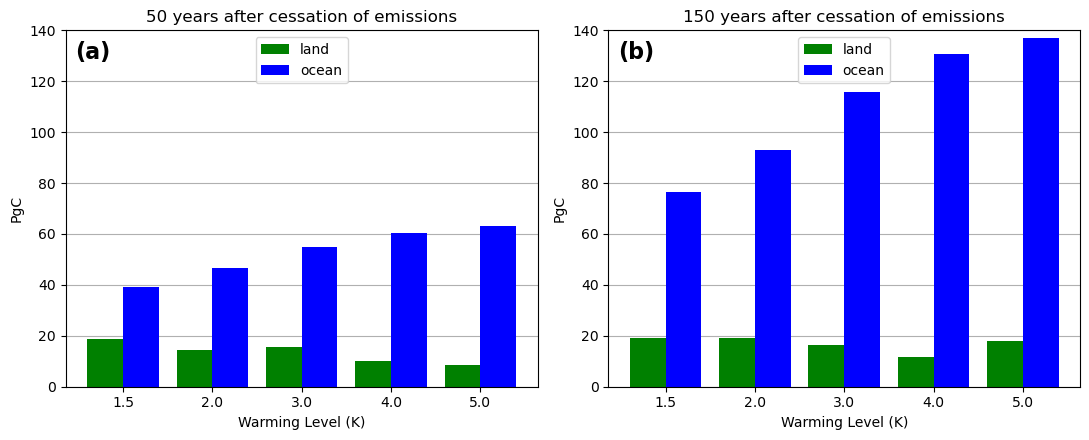

In [25]:
# Paper fig 4
# Total cumulative carbon bar plots (ensemble mean per GWL)

def _gwl_sort_key(gwl_label):
    return float(str(gwl_label).replace('K', ''))

ordered_gwls = sorted({SUITE_DICT[s][0] for s in suites}, key=_gwl_sort_key)
gwl_to_indices = {gwl: [idx for idx, s in enumerate(suites) if SUITE_DICT[s][0] == gwl] for gwl in ordered_gwls}

GWL_labels = [str(float(str(g).replace('K', ''))) for g in ordered_gwls]
x_ticks = np.arange(len(GWL_labels))
ZEC_yrs = [50, 150]

# Recompute member-level bars here to avoid notebook-state drift from other figure cells
total_ocn_co2_for_bars = []
total_nbp_for_bars = []
for ZEC_yr in ZEC_yrs:
    total_ocn_co2_yr = []
    total_nbp_yr = []
    for ocn_co2, nbp, suite in zip(total_ocn_co2s, total_nbps, suites):
        ocn = np.asarray(ocn_co2.data, dtype=float) * 10e-13
        land = np.asarray(nbp.data, dtype=float) * 10e-13
        ocn = ocn - ocn[0]
        land = land - land[0]

        i0 = max(0, ZEC_yr-10)
        i1 = min(len(ocn), ZEC_yr+10)
        total_ocn_co2_yr.append(float(np.nanmean(ocn[i0:i1])))
        total_nbp_yr.append(float(np.nanmean(land[i0:i1])))

    total_ocn_co2_for_bars.append(total_ocn_co2_yr)
    total_nbp_for_bars.append(total_nbp_yr)

fig, axes = plt.subplots(1, len(ZEC_yrs), figsize=(11,4.5))
if len(ZEC_yrs) == 1:
    axes = [axes]

w = 0.4
for i, (ocn_co2_bar, nbp_bar, yr, ax) in enumerate(zip(total_ocn_co2_for_bars, total_nbp_for_bars, ZEC_yrs, axes)):
    ocn_co2_bar_mean = [np.nanmean([ocn_co2_bar[k] for k in gwl_to_indices[gwl]]) for gwl in ordered_gwls]
    nbp_bar_mean = [np.nanmean([nbp_bar[k] for k in gwl_to_indices[gwl]]) for gwl in ordered_gwls]

    ax.bar(x_ticks - w/2, nbp_bar_mean, w, label='land', color='green')
    ax.bar(x_ticks + w/2, ocn_co2_bar_mean, w, label='ocean', color='blue')
    ax.legend(loc='upper center')

    ax.set_xlabel('Warming Level (K)')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(GWL_labels)
    ax.set_ylim(0, 140)
    ax.set_ylabel('PgC')
    ax.grid(axis='y')
    ax.set_axisbelow(True)

axes[0].text(0.02,0.92,'(a)', transform=axes[0].transAxes, fontsize=16, fontweight='bold')
axes[1].text(0.02,0.92,'(b)', transform=axes[1].transAxes, fontsize=16, fontweight='bold')
axes[0].set_title('50 years after cessation of emissions')
axes[1].set_title('150 years after cessation of emissions')

fig.tight_layout()


In [26]:
ramp_start_yr = int(np.min([get_yrs_from_time_cube(rt.coord("time"))[0] for rt in ramp_temps]))
window_size = 10

temp_series = []
land_series = []

for total_nbp, temp, suite in zip(total_nbps, temps, suites):
    temp_time = temp.coord("time")
    temp_time_converted = temp_time.units.num2date(temp_time.points)
    yrs_temp = np.asarray([temp_time.year for temp_time in temp_time_converted])
    yrs_temp = yrs_temp - ramp_start_yr
    temp = temp.data
    ramp_start_temp = temp[0]
    temp = [t - ramp_start_temp for t in temp]

    ze_temp = [t - temp[0] for t in temp]
    ze_yrs_temp = yrs_temp - yrs_temp[0]
    if window_size != 0:
        ze_temp = np.convolve(ze_temp, np.ones(window_size)/window_size, mode='valid')
        ze_yrs_temp = np.convolve(ze_yrs_temp, np.ones(window_size)/window_size, mode='valid')
    temp_series.append((suite, np.asarray(ze_yrs_temp), np.asarray(ze_temp) - ze_temp[0]))

    nbp_time = total_nbp.coord("time")
    nbp_time_converted = nbp_time.units.num2date(nbp_time.points)
    yrs_nbp = np.asarray([nbp_time.year for nbp_time in nbp_time_converted])
    total_nbp = total_nbp.data
    ze_yrs_nbp = yrs_nbp - yrs_nbp[0]
    land_series.append((suite, ze_yrs_nbp, (total_nbp - total_nbp[0]) * 10e-13))


/data/apps/sss/environments/default-2025_08_19/lib/python3.12/site-packages/iris/common/mixin.py:203: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


In [27]:
def _gwl_sort_key(gwl_label):
    return float(str(gwl_label).replace('K', ''))


def plot_ensemble_mean_only(ax, suite_series, *, linestyle='-'):
    grouped = {}
    for suite, x, y in suite_series:
        gwl = SUITE_DICT[suite][0]
        grouped.setdefault(gwl, []).append((np.asarray(x), np.asarray(y)))

    for gwl in sorted(grouped.keys(), key=_gwl_sort_key):
        x_mean, y_mean = overlap_mean_from_latest_start(grouped[gwl])
        if len(x_mean) == 0:
            continue
        ax.plot(
            x_mean,
            y_mean,
            color=SUITE_DICT[next(s for s in suites if SUITE_DICT[s][0] == gwl)][1],
            linewidth=ENSEMBLE_LINEWIDTH,
            alpha=0.95,
            linestyle=linestyle,
        )


abs_focn_series = []
abs_fland_series = []
zec_focn_series = []
zec_fland_series = []

for ocn_co2, nbp, co2, suite in zip(total_ocn_co2s, total_nbps, co2s, suites):
    yrs = np.asarray(get_yrs_from_time_cube(ocn_co2.coord("time")))

    ocn_co2 = ocn_co2.data * 10e-13 # convert from kg to Gt
    nbp = nbp.data * 10e-13 # convert from kg to Gt
    co2 = co2.data

    ocn_co2 = ocn_co2 - ocn_co2[0]
    nbp = nbp - nbp[0]

    fo_over_co2 = ocn_co2 / co2
    fl_over_co2 = nbp / co2

    f_ocean = R * fo_over_co2
    f_land = R * fl_over_co2

    roll_f_land = rolling_mean_on_arr(f_land[:-20], window_size=0)
    roll_f_ocn = rolling_mean_on_arr(f_ocean[:-20], window_size=0)
    roll_yrs = rolling_mean_on_arr(yrs[:-20], window_size=0)

    branch_roll_yrs = roll_yrs - roll_yrs[0]
    abs_focn_series.append((suite, yrs, f_ocean * -1))
    abs_fland_series.append((suite, yrs, f_land * -1))
    zec_focn_series.append((suite, branch_roll_yrs, roll_f_ocn - roll_f_land[0]))
    zec_fland_series.append((suite, branch_roll_yrs, roll_f_land - roll_f_land[0]))

# Ramp-up ensemble mean (across available ramp members)
ramp_abs_focn = []
ramp_abs_fland = []
for total_ocn_co2, total_nbp, co2 in zip(ramp_total_ocn_co2s, ramp_total_nbps, ramp_co2s):
    yrs = np.asarray(get_yrs_from_time_cube(total_ocn_co2.coord("time")))

    total_ocn_co2 = total_ocn_co2.data
    total_nbp = total_nbp.data
    co2 = co2.data

    fo_over_co2 = total_ocn_co2 / co2
    fl_over_co2 = total_nbp / co2

    f_ocean = R * fo_over_co2
    f_land = R * fl_over_co2

    ramp_abs_focn.append((yrs, f_ocean * -10e-13))
    ramp_abs_fland.append((yrs, f_land * -10e-13))


In [28]:
ZEC_yrs = [50, 150]
ordered_gwls = sorted({SUITE_DICT[s][0] for s in suites}, key=lambda g: float(str(g).replace('K','')))
gwl_to_indices = {gwl: [idx for idx, s in enumerate(suites) if SUITE_DICT[s][0] == gwl] for gwl in ordered_gwls}

f_ocean_zecs = []
f_land_zecs = []
plot_ocean_series = []
plot_land_series = []

for ZEC_yr in ZEC_yrs:
    f_ocean_zec_member = []
    f_land_zec_member = []

    for ocn_co2, nbp, co2, suite in zip(total_ocn_co2s, total_nbps, co2s, suites):
        yrs = np.asarray(get_yrs_from_time_cube(ocn_co2.coord('time')))

        ocn_co2 = ocn_co2.data * 10e-13
        nbp = nbp.data * 10e-13
        co2 = co2.data

        ocn_co2 = ocn_co2 - ocn_co2[0]
        nbp = nbp - nbp[0]

        fo_over_co2 = ocn_co2 / co2
        fl_over_co2 = nbp / co2

        f_ocean = R * fo_over_co2
        f_land = R * fl_over_co2

        f_ocean_zec_member.append(np.mean(f_ocean[ZEC_yr-10:ZEC_yr+10]) * -1)
        f_land_zec_member.append(np.mean(f_land[ZEC_yr-10:ZEC_yr+10]) * -1)

        roll_f_land = rolling_mean_on_arr(f_land[:-20], window_size=0)
        roll_yrs = rolling_mean_on_arr(yrs[:-20], window_size=0)

        ze_yrs = yrs - yrs[0]
        roll_yrs = roll_yrs - roll_yrs[0]

        if ZEC_yr == ZEC_yrs[0]:
            plot_ocean_series.append((suite, ze_yrs, f_ocean))
            plot_land_series.append((suite, roll_yrs, roll_f_land))

    # Collapse to GWL ensemble means for bar plotting downstream
    f_ocean_zec_mean = [np.nanmean([f_ocean_zec_member[k] for k in gwl_to_indices[gwl]]) for gwl in ordered_gwls]
    f_land_zec_mean = [np.nanmean([f_land_zec_member[k] for k in gwl_to_indices[gwl]]) for gwl in ordered_gwls]

    f_ocean_zecs.append(f_ocean_zec_mean)
    f_land_zecs.append(f_land_zec_mean)

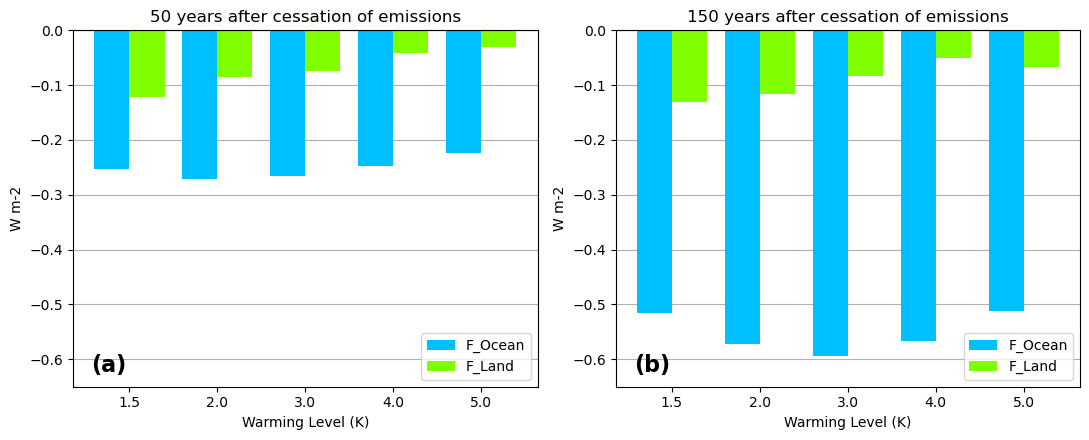

In [29]:
# Paper fig 5
# Radiative forcing contributions from land and ocean bar plots

GWL_labels = [str(float(str(g).replace('K',''))) for g in ordered_gwls]
x_ticks = np.arange(len(GWL_labels))

fig, axes = plt.subplots(1, len(ZEC_yrs), figsize=(11,4.5))
w = 0.4
for i, (f_ocean_zec, f_land_zec, yr, ax) in enumerate(zip(f_ocean_zecs, f_land_zecs, ZEC_yrs, axes)):
    ax.bar(x_ticks - w/2, f_ocean_zec, w, label='F_Ocean', color='deepskyblue')
    ax.bar(x_ticks + w/2, f_land_zec, w, label='F_Land', color='chartreuse')
    ax.legend(loc='lower right')

    ax.axhline(y=0, linestyle='--', color='black')
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(GWL_labels)
    ax.grid(axis='y')
    ax.set_axisbelow(True)
    ax.set_xlabel('Warming Level (K)')
    ax.set_ylim(-0.65,0)
    ax.set_ylabel('W m-2')

axes[0].text(0.04,0.04,'(a)', transform=axes[0].transAxes, fontsize=16, fontweight='bold')
axes[1].text(0.04,0.04,'(b)', transform=axes[1].transAxes, fontsize=16, fontweight='bold')
axes[0].set_title('50 years after cessation of emissions')
axes[1].set_title('150 years after cessation of emissions')
fig.tight_layout()



In [30]:
# Supplementary figures

In [31]:
# Quantify relative CSC/CCW contributions across GWL and time horizons.
gwl_vals = np.array([float(str(g).replace('K', '')) for g in ordered_gwls], dtype=float)

def _ensemble_mean_term_by_gwl(term_by_time, time_idx):
    out = []
    for gwl in ordered_gwls:
        vals = np.asarray([term_by_time[time_idx][k] for k in gwl_to_indices[gwl]], dtype=float)
        vals = vals[np.isfinite(vals)]
        out.append(float(np.mean(vals)) if vals.size else np.nan)
    return np.asarray(out, dtype=float)

# Ensemble means as functions of GWL, for each analysis time (e.g., 50y, 150y)
ccw_mean_by_time = {_nyr: _ensemble_mean_term_by_gwl(CWs, i) for i, _nyr in enumerate(nyrs)}
csc_mean_by_time = {_nyr: _ensemble_mean_term_by_gwl(CCs, i) for i, _nyr in enumerate(nyrs)}


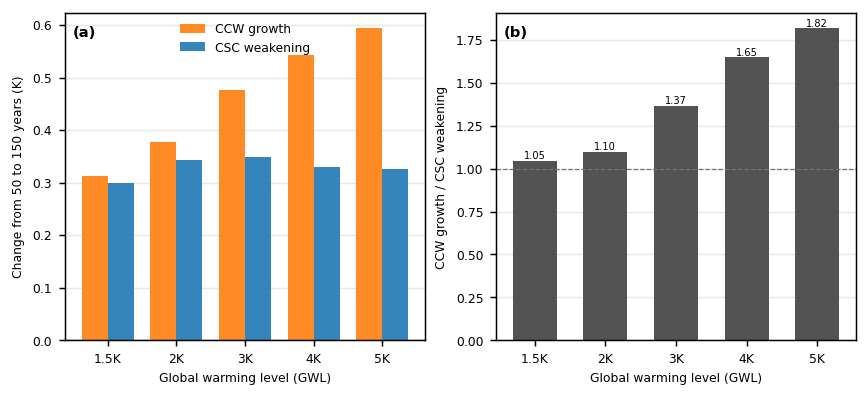

In [32]:
# Paper fig S2
# (a) Time-growth components(CCW growth and CSC weakening),
# (b) CCW growth / CSC weakening ratio in extra time-growth.

if len(nyrs) < 2:
    print('Need at least two nyrs entries (e.g., 50 and 150) for this diagnostic figure.')
else:
    t0, t1 = nyrs[0], nyrs[1]

    # Time-growth components
    dccw_dt = ccw_mean_by_time[t1] - ccw_mean_by_time[t0]
    dcsc_dt = csc_mean_by_time[t1] - csc_mean_by_time[t0]

    # dCCW(150-50) / |dCSC(150-50)|
    ratio = np.divide(
        dccw_dt,
        np.abs(dcsc_dt),
        out=np.full_like(dccw_dt, np.nan, dtype=float),
        where=np.abs(dcsc_dt) > 0,
    )

    gwl_labels = [f'{g:g}K' for g in gwl_vals]
    x = np.arange(len(gwl_vals), dtype=float)

    col_ccw = 'tab:orange'
    col_csc = 'tab:blue'
    col_ratio = '0.25'

    scale = 2/3
    fig, axes = plt.subplots(1, 2, figsize=(11.5 * scale, 4.8 * scale), dpi=int(200 * scale))
    fs_label = 10 * scale
    fs_tick = 10 * scale
    fs_legend = 10 * scale
    fs_annot = 8 * scale
    fs_panel = 12 * scale
    lw_base = 1.0 * scale

    # Panel (a): absolute change over time by process, at each GWL
    ax = axes[0]
    ax.grid(True, axis='y', alpha=0.28)
    ax.set_axisbelow(True)
    width = 0.38
    ax.bar(x - width / 2, dccw_dt, width=width, color=col_ccw, alpha=0.9, label='CCW growth')
    ax.bar(x + width / 2, -dcsc_dt, width=width, color=col_csc, alpha=0.9, label='CSC weakening')
    ax.axhline(0.0, color='0.4', lw=lw_base)
    ax.set_xticks(x)
    ax.set_xticklabels(gwl_labels)
    ax.tick_params(axis='both', labelsize=fs_tick)
    ax.set_xlabel('Global warming level (GWL)', fontsize=fs_label)
    ax.set_ylabel('Change from 50 to 150 years (K)', fontsize=fs_label)
    ax.legend(frameon=False, loc='upper center', fontsize=fs_legend)

    # Panel (b): ratio CCW growth / CSC weakening 
    ax2 = axes[1]
    ax2.grid(True, axis='y', alpha=0.28)
    ax2.set_axisbelow(True)
    ax2.bar(x, ratio, width=0.62, color=col_ratio, alpha=0.9)
    ax2.axhline(1.0, color='0.45', lw=lw_base, ls='--')
    ax2.set_xticks(x)
    ax2.set_xticklabels(gwl_labels)
    ax2.tick_params(axis='both', labelsize=fs_tick)
    ax2.set_xlabel('Global warming level (GWL)', fontsize=fs_label)
    ax2.set_ylabel('CCW growth / CSC weakening', fontsize=fs_label)
    # ax2.set_ylabel(r'$\Delta_{150-50} CCW / |\Delta_{150-50} CSC|$')

    for i, r in enumerate(ratio):
        if np.isfinite(r):
            ax2.text(i, r, f'{r:.2f}', ha='center', va='bottom', fontsize=fs_annot)

    axes[0].text(0.02, 0.96, '(a)', transform=axes[0].transAxes, va='top', fontweight='bold', fontsize=fs_panel)
    axes[1].text(0.02, 0.96, '(b)', transform=axes[1].transAxes, va='top', fontweight='bold', fontsize=fs_panel)


In [41]:
# Load Paper fig S3 plotted data from local files
s3_dir = './paper_local_data/paper_fig_s3_inputs'

class _LocalCube:
    def __init__(self, years, data):
        self._years = np.asarray(years)
        self.data = np.asarray(data)
        self.coord = lambda name: self._coord(name)
    def _coord(self, name):
        if name != 'time':
            raise ValueError('Only time coord supported in local wrapper')
        class _U:
            def __init__(self, y): self._y=y
            def num2date(self, points):
                class _D:
                    def __init__(self, year): self.year = int(year)
                return [_D(v) for v in self._y]
        class _C:
            def __init__(self, y):
                self.points = np.arange(len(y))
                self.units = _U(y)
        return _C(self._years)

for suite in suites:
    fp = f"{s3_dir}/{suite}__s3_inputs.npz"
    if not os.path.exists(fp):
        raise FileNotFoundError(f"Missing S3 input file: {fp}")

r_suite = ramp_suites[0]
r_fp = f"{s3_dir}/{r_suite}__s3_ramp_inputs.npz"
if not os.path.exists(r_fp):
    raise FileNotFoundError(f"Missing S3 ramp input file: {r_fp}")

total_ocn_co2s_local = []
total_nbps_local = []
for suite in suites:
    z = np.load(f"{s3_dir}/{suite}__s3_inputs.npz")
    total_ocn_co2s_local.append(_LocalCube(z['yrs'], z['ocn']))
    total_nbps_local.append(_LocalCube(z['yrs'], z['nbp']))

total_ocn_co2s = total_ocn_co2s_local
total_nbps = total_nbps_local

rz = np.load(r_fp)
ramp_total_ocn_co2s = [_LocalCube(rz['yrs'], rz['ocn'])]
ramp_total_nbps = [_LocalCube(rz['yrs'], rz['nbp'])]


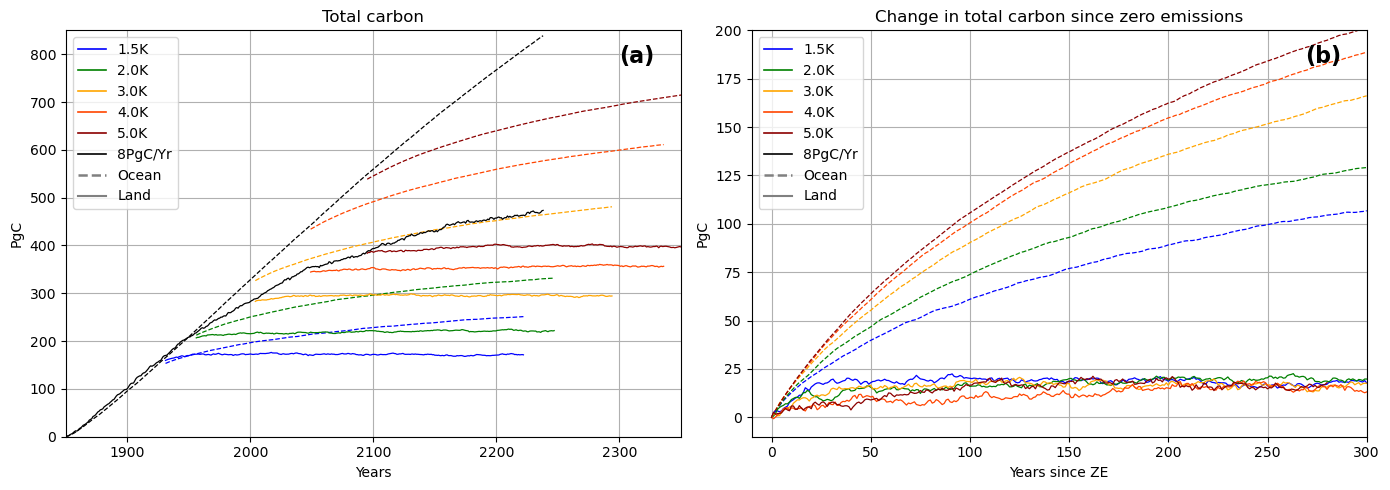

In [34]:
# Paper fig S3
# plot cumulative carbon time series
fig, ax = plt.subplots(1,2, figsize=(14, 5))

total_ocn_co2_for_bars = []
total_nbp_for_bars = []
ZEC_yrs = [50, 150]

def _plot_ensemble_mean_only(ax, suite_series, *, linestyle='-'):
    grouped = {}
    for suite, x, y in suite_series:
        gwl = SUITE_DICT[suite][0]
        grouped.setdefault(gwl, []).append((np.asarray(x), np.asarray(y)))

    for gwl in sorted(grouped.keys(), key=lambda g: float(str(g).replace('K',''))):
        x_mean, y_mean = overlap_mean_from_latest_start(grouped[gwl])
        if len(x_mean) == 0:
            continue
        color = SUITE_DICT[next(s for s in suites if SUITE_DICT[s][0] == gwl)][1]
        ax.plot(x_mean, y_mean, color=color, linewidth=ENSEMBLE_LINEWIDTH, linestyle=linestyle)

abs_ocn_series = []
abs_land_series = []
ze_ocn_series = []
ze_land_series = []

for i, (total_ocn_co2, total_nbp, suite) in enumerate(zip(total_ocn_co2s, total_nbps, suites)):
    time = total_ocn_co2.coord("time")
    time_converted = time.units.num2date(time.points)
    yrs = np.asarray([time.year for time in time_converted])

    total_ocn_co2 = total_ocn_co2.data
    total_nbp = total_nbp.data

    abs_ocn_series.append((suite, yrs, total_ocn_co2 * 10e-13))
    abs_land_series.append((suite, yrs, total_nbp * 10e-13))

    ze_yrs = yrs - yrs[0]
    ze_ocn_series.append((suite, ze_yrs, (total_ocn_co2 - total_ocn_co2[0]) * 10e-13))
    if i == len(suites)-1:
        ze_land_series.append((suite, ze_yrs[:-20], ((total_nbp - total_nbp[0]) * 10e-13)[:-20]))
    else:
        ze_land_series.append((suite, ze_yrs, (total_nbp - total_nbp[0]) * 10e-13))

_plot_ensemble_mean_only(ax[0], abs_ocn_series, linestyle='--')
_plot_ensemble_mean_only(ax[0], abs_land_series, linestyle='-')
_plot_ensemble_mean_only(ax[1], ze_ocn_series, linestyle='--')
_plot_ensemble_mean_only(ax[1], ze_land_series, linestyle='-')

for total_ocn_co2, total_nbp, suite in zip([ramp_total_ocn_co2s[0]], [ramp_total_nbps[0]], ramp_suites):
    time = total_ocn_co2.coord("time")
    time_converted = time.units.num2date(time.points)
    yrs = [time.year for time in time_converted]
    total_ocn_co2 = total_ocn_co2.data
    total_nbp = total_nbp.data
    ax[0].plot(yrs, total_ocn_co2 * 10e-13, color=RAMP_DICT[suite][1], linewidth=ENSEMBLE_LINEWIDTH, linestyle="--")
    ax[0].plot(yrs, total_nbp * 10e-13, color=RAMP_DICT[suite][1], linewidth=ENSEMBLE_LINEWIDTH, linestyle="-")

ax[0].set_xlabel('Years')
ax[0].set_title('Total carbon')
ax[0].grid()
ax[0].set_ylabel('PgC')
ax[0].set_xlim(1850, 2350)
ax[0].set_ylim(0,850)
from matplotlib.lines import Line2D
ordered_gwls = sorted({SUITE_DICT[s][0] for s in suites}, key=lambda g: float(str(g).replace('K','')))
legend_gwl = [
    Line2D([0], [0], color=SUITE_DICT[next(s for s in suites if SUITE_DICT[s][0] == g)][1], linestyle='-', linewidth=1.2, label=g)
    for g in ordered_gwls
]
legend_ramp = [Line2D([0], [0], color='black', linestyle='-', linewidth=1.2, label=RAMP_DICT[ramp_suites[0]][0])]
legend_all = legend_gwl + legend_ramp + legend_lines
ax[0].legend(handles=legend_all, loc='best')
ax[1].legend(handles=legend_all, loc='best')

ax[1].set_xlabel('Years since ZE')
ax[1].set_title('Change in total carbon since zero emissions')
ax[1].grid()
ax[1].set_xlim(-10, 300)
ax[1].set_ylim(-10, 200)
ax[1].set_ylabel('PgC')

ax[0].text(0.9,0.92,'(a)', transform=ax[0].transAxes, fontsize=16, fontweight="bold")
ax[1].text(0.9,0.92,'(b)', transform=ax[1].transAxes, fontsize=16, fontweight="bold")

plt.tight_layout()


In [ ]:
import xarray as xr
COLUMN_MAPPING = {
    'toa': {
        'netcl': 1, 'netcf': 2, 'osw': 3, 'closw': 4, 'swcf': 5,
        'olw': 6, 'clolw': 7, 'lwcf': 8, 'net': 9
    },
    'npp': {
        'npp': 1, 'gpp': 2, 'rs': 3, 'nbp': 4, 'nep': 5, 'l1': 6, 'l2': 7
    },
    'cv_cs': {
        'cv': 1, 'cs': 2
    }
}

STABILIZATION_SUITE_DICT = {
    'u-cy837': '1.5K', 'u-cz834': '1.5K', 'u-da087': '1.5K',
    'u-cy838': '2.0K', 'u-cz855': '2.0K', 'u-da266': '2.0K',
    'u-cz375': '3.0K', 'u-db587': '3.0K', 'u-db597': '3.0K',
    'u-cz376': '4.0K', 'u-db723': '4.0K', 'u-db733': '4.0K',
    'u-cz377': '5.0K', 'u-db731': '5.0K', 'u-dc324': '5.0K',
}

RUP_SUITE_DICT = {
    'u-cx209': '8PgC/yr',
    'u-cw988': '8PgC/yr',
    'u-cw989': '8PgC/yr',
}

ALL_SUITE_DICT = STABILIZATION_SUITE_DICT | RUP_SUITE_DICT

PLOT_DICT = {
    '8PgC/yr': 'black',
    '1.5K': 'blue',
    '2.0K': 'green',
    '3.0K': 'orange',
    '4.0K': 'orangered',
    '5.0K': 'darkred',
}


In [39]:
def load_data_as_xarray_for_grouped_suites(dir, suite, var_name):

    file_path = os.path.join(dir, suite, var_name)
    if os.path.exists(file_path + '.dat'):
        data = np.loadtxt(file_path + '.dat', skiprows=1)
        yr = data[:, 0] 
        return yr, data[:, 1:] 
    
    elif os.path.exists(file_path + '.nc'):
        ds = xr.open_dataset(file_path + '.nc')
        yr = ds['time'].values
        
        if var_name in COLUMN_MAPPING:
            data = ds[list(COLUMN_MAPPING[var_name].keys())].to_array().values.T
        else:
            data = ds[var_name].values
        
        return yr, data


def load_grouped_suites_for_plotting(grouped_suites, data_dir, var_name, column_to_plot=None):
    processed_data = {}    
    for value, suites in grouped_suites.items():
        processed_data[value] = []
        for suite in suites:
            years, data = load_data_as_xarray_for_grouped_suites(data_dir, suite, var_name)
            if column_to_plot is not None:
                col_idx = COLUMN_MAPPING[var_name][column_to_plot] - 1
                suite_data = data[:, col_idx]
            else:
                suite_data = data[:]
            processed_data[value].append((years, suite_data))
    
    return processed_data

grouped_suites = {
    value: [suite for suite in ALL_SUITE_DICT if ALL_SUITE_DICT[suite] == value] 
    for value in list(PLOT_DICT.keys())
}

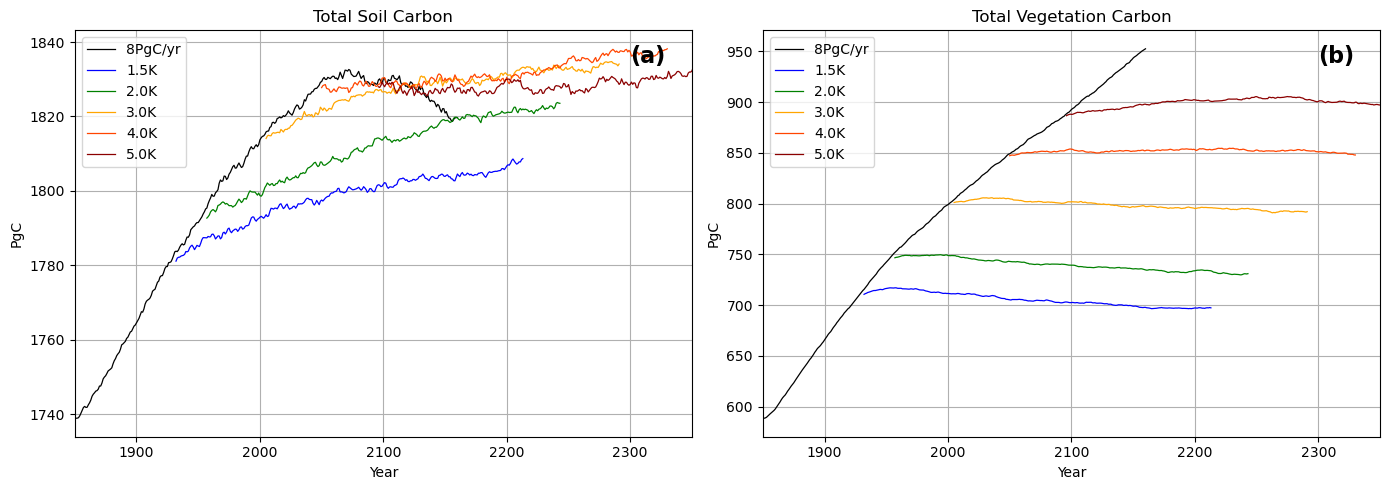

In [40]:
# Paper fig S4
# Plot veg and soil carbon

s4_dir = './paper_local_data/paper_fig_s4_inputs'
for suite in ALL_SUITE_DICT.keys():
    suite_dir = os.path.join(s4_dir, suite)
    dat_fp = os.path.join(suite_dir, 'cv_cs.dat')
    nc_fp = os.path.join(suite_dir, 'cv_cs.nc')
    if not (os.path.exists(dat_fp) or os.path.exists(nc_fp)):
        raise FileNotFoundError(f"Missing S4 source for suite {suite}: {suite_dir}")

soil_carbon = load_grouped_suites_for_plotting(grouped_suites, s4_dir, 'cv_cs', 'cs')
veg_carbon = load_grouped_suites_for_plotting(grouped_suites, s4_dir, 'cv_cs', 'cv')

fig, axs = plt.subplots(1,2, figsize=(14, 5))

for value, data_list in soil_carbon.items():
    member_series = []
    for years, suite_data in data_list:
        member_series.append((np.asarray(years), np.asarray(suite_data)))

    x_mean, y_mean = overlap_mean_from_latest_start(member_series)
    if len(x_mean) > 0:
        axs[0].plot(x_mean, y_mean, color=PLOT_DICT[value], linewidth=ENSEMBLE_LINEWIDTH)

axs[0].set_title('Total Soil Carbon')
axs[0].set_ylabel('PgC')
axs[0].set_xlabel('Year')
axs[0].set_xlim(1850,2350)
axs[0].grid()

for value, data_list in veg_carbon.items():
    member_series = []
    for years, suite_data in data_list:
        member_series.append((np.asarray(years), np.asarray(suite_data)))

    x_mean, y_mean = overlap_mean_from_latest_start(member_series)
    if len(x_mean) > 0:
        axs[1].plot(x_mean, y_mean, color=PLOT_DICT[value], linewidth=ENSEMBLE_LINEWIDTH)

axs[1].set_title('Total Vegetation Carbon')
axs[1].set_ylabel('PgC')
axs[1].set_xlabel('Year')
axs[1].set_xlim(1850,2350)
axs[1].grid()

value_order = [value for value in PLOT_DICT.keys() if value in soil_carbon.keys() or value in veg_carbon.keys()]
ensemble_handles = [
    Line2D([0], [0], color=PLOT_DICT[value], linewidth=ENSEMBLE_LINEWIDTH, label=value)
    for value in value_order
]
axs[0].legend(handles=ensemble_handles, loc='best')
axs[1].legend(handles=ensemble_handles, loc='best')

axs[0].text(0.9,0.92,'(a)', transform=axs[0].transAxes, fontsize=16, fontweight='bold')
axs[1].text(0.9,0.92,'(b)', transform=axs[1].transAxes, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

